<a href="https://colab.research.google.com/github/Takfes/notes-deep-learning/blob/main/02_activation_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

### Settings


In [2]:
def plot_activation(x, y, y_derivative, label):
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, label=f"{label} function")
    plt.plot(x, y_derivative, label=f"derivative of {label}", linestyle="--")
    plt.title(f"{label} and its derivative")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.show()

In [3]:
x = np.linspace(-10, 10, 100)

### Sigmoid

$$ \text{Sigmoid}(x) = \frac{1}{1 + e^{-x}} $$


In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    sig = sigmoid(x)
    return sig * (1 - sig)

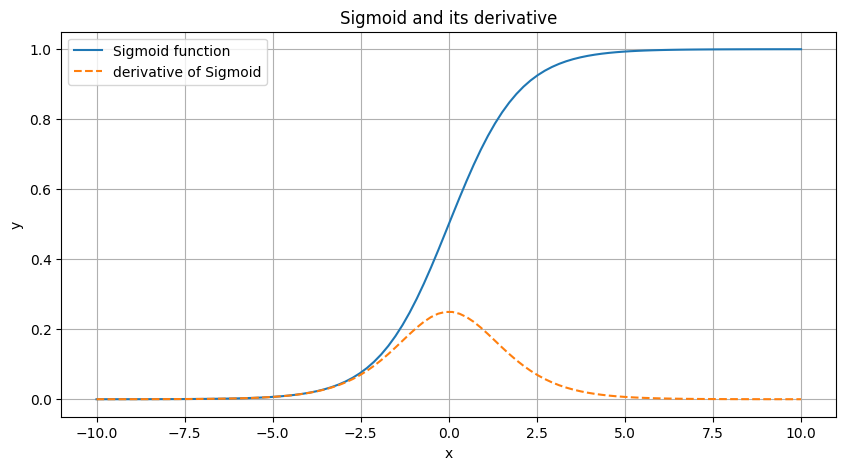

In [5]:
y_sigmoid = sigmoid(x)
y_sigmoid_derivative = sigmoid_derivative(x)
plot_activation(x, y_sigmoid, y_sigmoid_derivative, "Sigmoid")

### Tanh (Hyperbolic Tangent)

$$ \tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} $$


In [6]:
def tanh(x):
    return np.tanh(x)


def dtanh_derivative(x):
    return 1 - np.tanh(x) ** 2

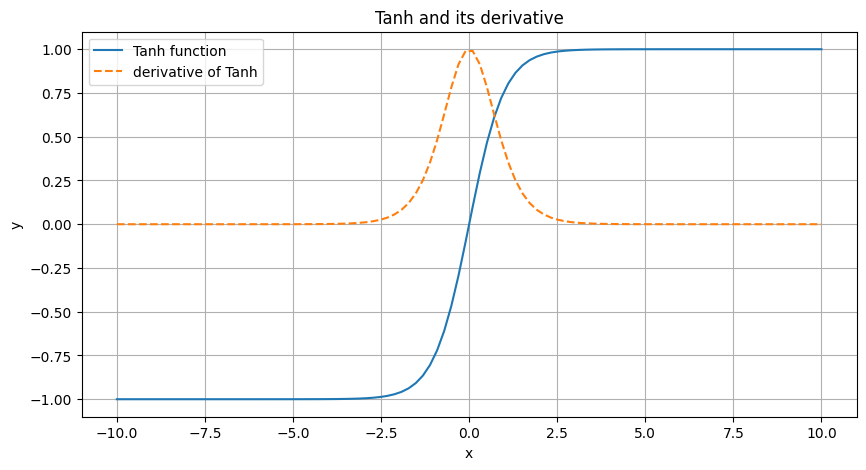

In [7]:
y_tanh = tanh(x)
y_tanh_derivative = dtanh_derivative(x)
plot_activation(x, y_tanh, y_tanh_derivative, "Tanh")

### Softmax

$$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} $$


In [8]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)


def softmax_derivative(x):
    softm = softmax(x)
    return softm * (1 - softm)

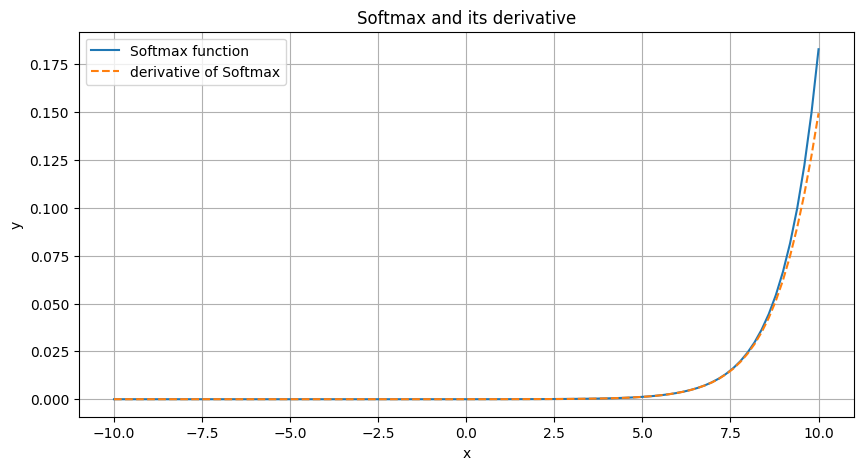

In [9]:
y_softmax = softmax(x)
y_softmax_derivative = softmax_derivative(x)
plot_activation(x, y_softmax, y_softmax_derivative, "Softmax")

## Softplus

$$ \text{Softplus}(x) = \ln(1 + e^x) $$


In [10]:
def softplus(x):
    return np.log1p(np.exp(x))


def softplus_derivative(x):
    return 1 / (1 + np.exp(-x))  # This is the sigmoid function

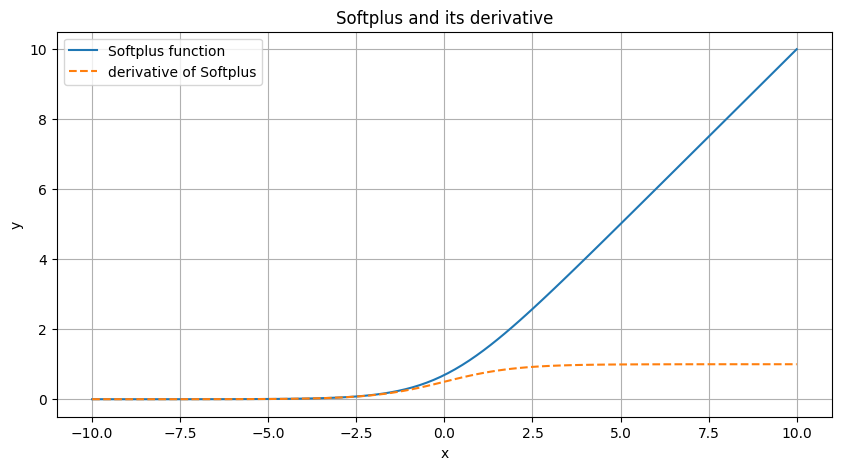

In [11]:
y_softplus = softplus(x)
y_softplus_derivative = softplus_derivative(x)
plot_activation(x, y_softplus, y_softplus_derivative, "Softplus")

### ReLU

$$ \text{ReLU}(x) = \max(0, x) $$


In [12]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return np.where(x > 0, 1, 0)

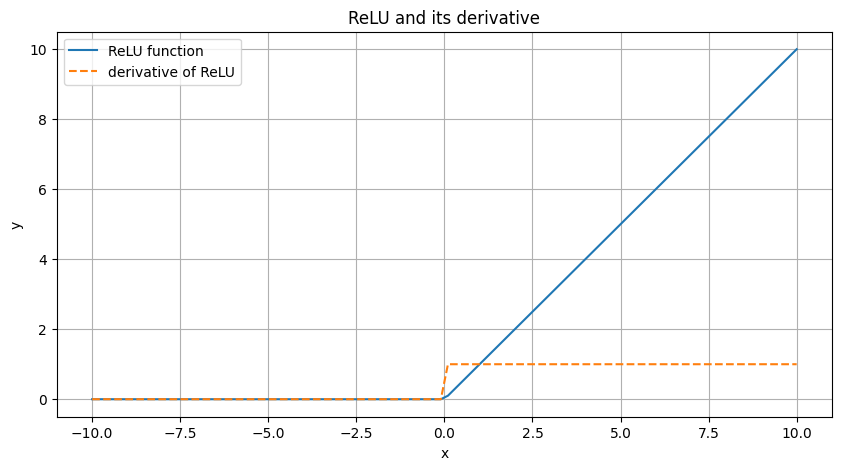

In [13]:
y_relu = relu(x)
y_relu_derivative = relu_derivative(x)
plot_activation(x, y_relu, y_relu_derivative, "ReLU")

### ELU (Exponential Linear Unit)

$$
\text{ELU}(x) = \begin{cases}
x & \text{if } x > 0 \\
\alpha(e^x - 1) & \text{if } x \leq 0
\end{cases}
$$


In [14]:
def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))


def elu_derivative(x, alpha=1.0):
    return np.where(x > 0, 1, alpha * np.exp(x))

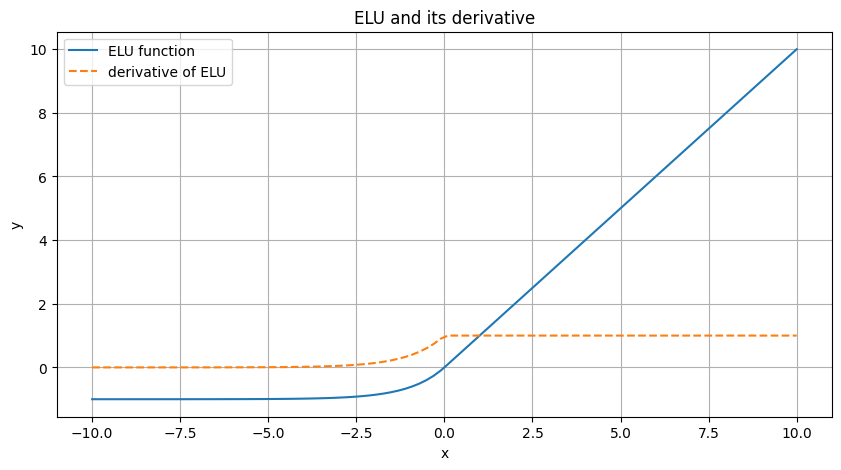

In [15]:
y_elu = elu(x)
y_elu_derivative = elu_derivative(x)
plot_activation(x, y_elu, y_elu_derivative, "ELU")

### GELU (Gaussian Error Linear Unit)

$$ \text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right] $$

Approximation: $$ \text{GELU}(x) \approx 0.5x\left[1 + \tanh\left(\sqrt{\frac{2}{\pi}}\left(x + 0.044715x^3\right)\right)\right] $$


In [16]:
def gelu(x):
    # Approximation formula
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))


def gelu_derivative(x):
    # Derivative of the approximation
    tanh_arg = np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)
    tanh_val = np.tanh(tanh_arg)
    sech2_val = 1 - tanh_val**2

    return 0.5 * (1 + tanh_val) + 0.5 * x * sech2_val * np.sqrt(2 / np.pi) * (
        1 + 3 * 0.044715 * x**2
    )

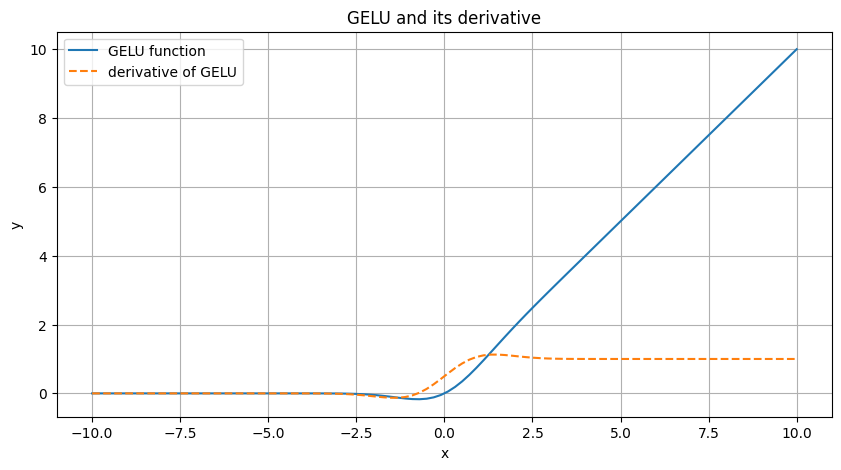

In [17]:
y_gelu = gelu(x)
y_gelu_derivative = gelu_derivative(x)
plot_activation(x, y_gelu, y_gelu_derivative, "GELU")